Before you submit this assignment, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell $\rightarrow$ Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE".

# ES98E Assignment 7 - Unsupervised Learning

## Workshop Aims

- Explore dimensionality reduction with PCA on image and molecular data
- Apply $K$-means clustering to identify patterns in high-dimensional data
- Apply unsupervised learning to analyse molecular conformations from simulations
- Build a simple generative model using Gaussian Mixture Models

**Note**: *The maximum available points for this assignment is 120: 100 points for the core material that everyone is expected to attempt, and 20 points for extension material which is optional, but assessed. The highest percentage you could get on this assignment without attempting the extension material is 100/120 = 83.3%*

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

# Customize default plotting style
%matplotlib inline
import seaborn as sns
sns.set_context('talk')

In [2]:
plt.rcParams["figure.figsize"] = (10, 8)

## Overview of MNIST dataset

In this workshop we will be exploring the widely used [MNIST dataset](https://en.wikipedia.org/wiki/MNIST_database) of handwritten digits. This contains inputs $X$ consisting of 60,000 training images and 10,000 test images, each of dimension $28\times28$ pixels, and the corresponding digit labels $y$ from zero to nine (stored as character strings, not integers).

Since our focus is on unsupervised learning in this workshop we will primarily be using the inputs $X$ in our analysis.

We first download the [dataset](https://www.openml.org/d/554), rescale the inputs integers between 0 and 255 to real numbers in $[0,1]$, and split into training and test sets. This will take a couple of minutes the first time you run it, but will be faster in future.

In [3]:
# Load data
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False, 
                    data_home=os.getcwd(), parser='auto',
                    cache=True)
X = X / 255.0

# Split data into train partition and test partition
np.random.seed(1)
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    random_state=0, test_size=10000)

You are provided with a function to show a single digit, optionally with the associated label and optionally using an existing Axes object. Here is a demo:

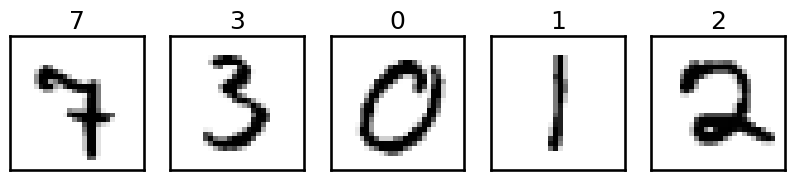

In [4]:
def show_digit_image(data, label=None, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(3, 3))
    ax.imshow(data.reshape((28, 28)), cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set(xticks=[], xticklabels=[], yticks=[], yticklabels=[], title=label)

fig, axs = plt.subplots(1, 5)
for i in range(5):
    show_digit_image(X_train[i], y_train[i], ax=axs[i])

## Part 1. Principal Component Analysis

In the first part of the workshop we will apply PCA to this dataset.

### Question 1.a

**Apply PCA to all the images of nines in `X_train` using 128 principal components**

- Complete the code below using the same variable names
- Extract all the 9s from the training dataset (i.e. the entries in `X_train` where `y_train == '9'`)
- Use the sklearn [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) class with the `whiten=True` optional argument. This rescales the principal components by the singular values to ensure they are uncorrelated and each have unit variance.

<div align="right">[5 points]</div>

In [5]:
from sklearn.decomposition import PCA

X_train_9 = X_train[y_train == '9']
pca = PCA(n_components=128, whiten=True)

pca.fit(X_train_9)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",128
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",True
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD

In [6]:
assert X_train_9.shape == (5989, 784)
assert isinstance(pca, PCA)
assert pca.whiten
assert pca.components_.shape == (128, 784)
assert pca.explained_variance_ratio_.sum() > 0.95

### Question 1.b

**Visualise and interpret the PCA results**

1. Plot the cumulative fraction of variance explained as a function of the number of principal components
2. Visualise the mean image and the first 4 principal components as images using `show_digit_image()`

<div align="right">[5 points]</div>

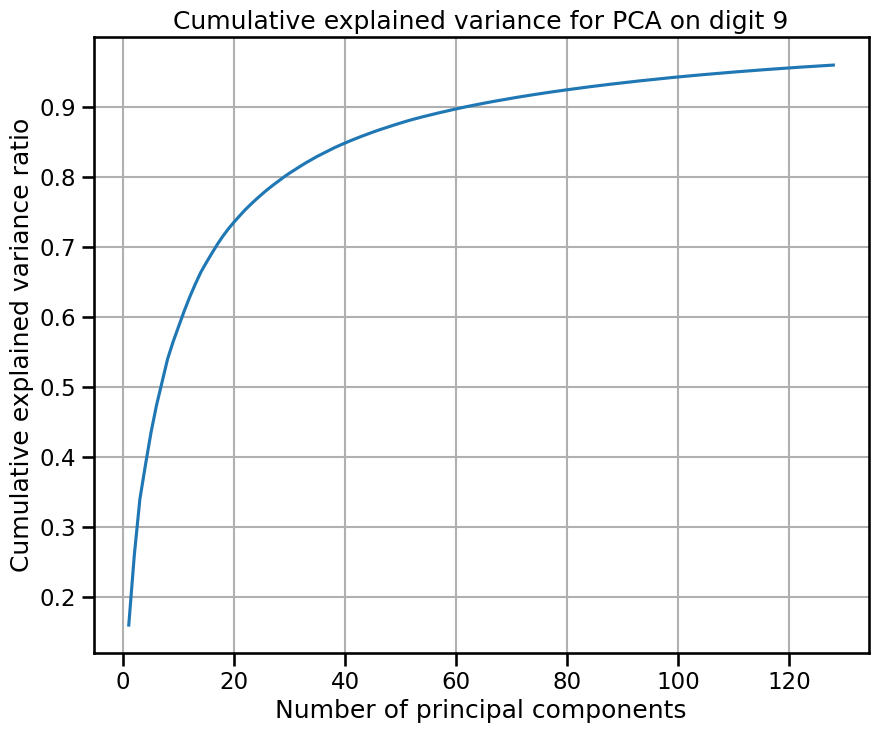

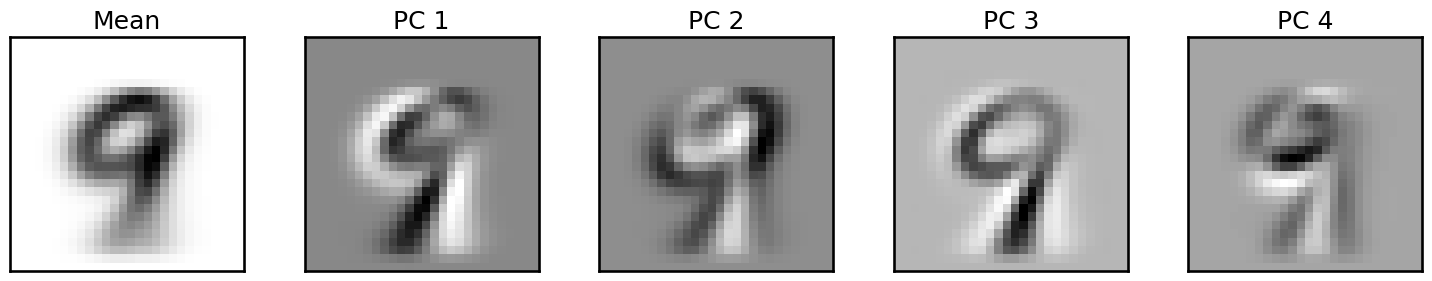

In [7]:
cum_fraction_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure()
plt.plot(np.arange(1, len(cum_fraction_var) + 1), cum_fraction_var)
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance ratio")
plt.title("Cumulative explained variance for PCA on digit 9")
plt.grid(True)
plt.show()

# mean image and first 4 PCs 
fig, axs = plt.subplots(1, 5, figsize=(15, 3))

show_digit_image(pca.mean_, label="Mean", ax=axs[0])

for i in range(4):
    show_digit_image(pca.components_[i], label=f"PC {i+1}", ax=axs[i+1])

plt.tight_layout()
plt.show()

### Question 1.c

**Explore the PCA latent space**

Apply your PCA transformation to all the nines in the training set and produce a scatter plot of the first two principal components. Identify a few example images at different locations in the latent space and comment on how the visual appearance of the digits varies across the space.

<div align="right">[10 points]

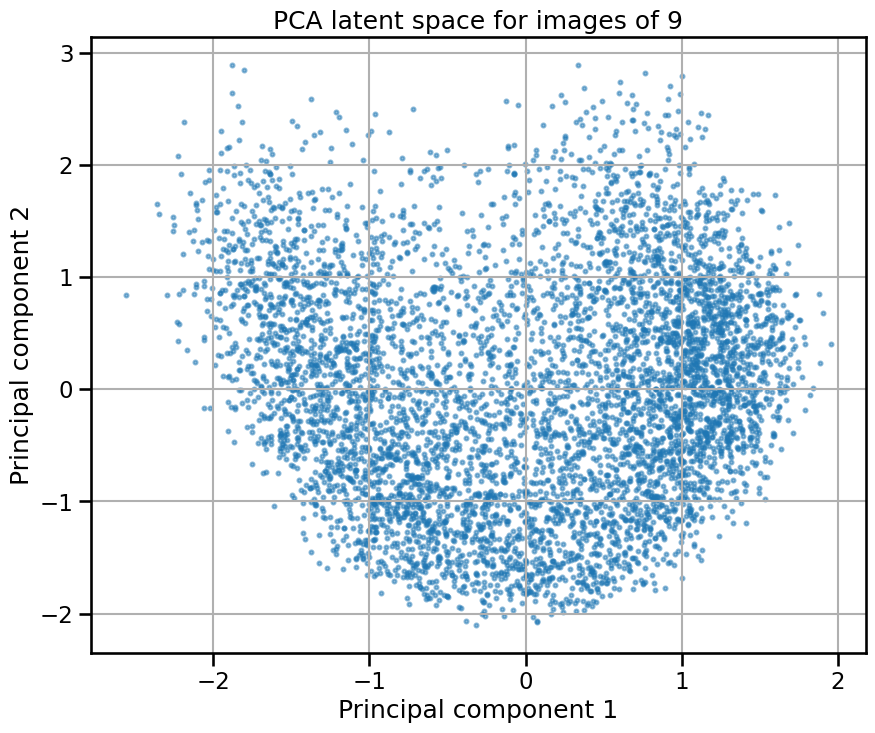

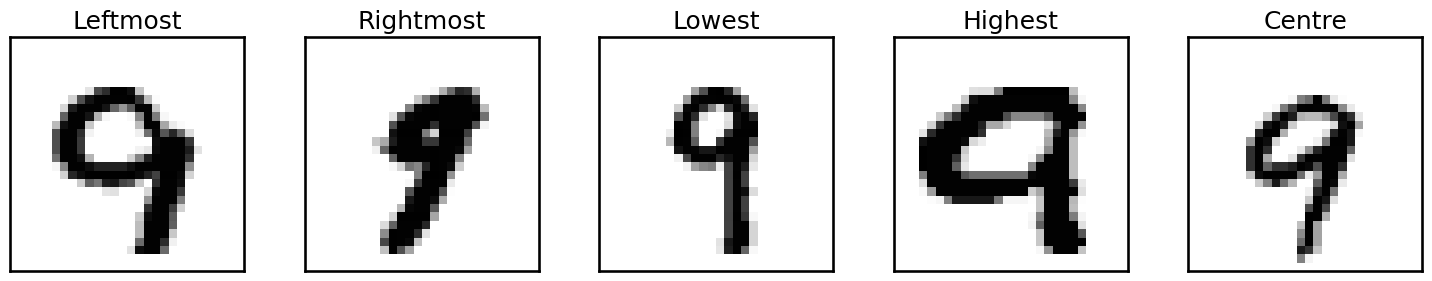

In [8]:
latent_train_9 = pca.transform(X_train_9)
plt.figure()
plt.scatter(latent_train_9[:, 0], latent_train_9[:, 1], s=8, alpha=0.5)
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.title("PCA latent space for images of 9")
plt.grid(True)
plt.show()

l = np.argmin(latent_train_9[:, 0])
r = np.argmax(latent_train_9[:, 0])
b = np.argmin(latent_train_9[:, 1])
t = np.argmax(latent_train_9[:, 1])

centre = np.mean(latent_train_9[:, :2], axis=0)
c = np.argmin(np.sum((latent_train_9[:, :2] - centre)**2, axis=1))

example_indices = [l, r, b, t, c]
example_labels = ["Leftmost", "Rightmost", "Lowest", "Highest", "Centre"]

fig, axs = plt.subplots(1, 5, figsize=(15, 3))
for ax, idx, label in zip(axs, example_indices, example_labels):
    show_digit_image(X_train_9[idx], label=label, ax=ax)

plt.tight_layout()
plt.show()

The PCA latent spaces is in the shape of a cloud, showing that variations in the number 9s from stylistic differences. When moving across the first PC (horizontal), the digits vary by thickness and slant of the pen's stroke. For the second PC (vertical), this captures the curvature of the tail and the loop size for the handwritten 9s. The latent space represents changes in handwriting style, where extremities reflect atypical/exaggerated handwriting styles and central points are typical representations of the number 9.

### Question 1.d

**Use your PCA model trained on nines to reconstruct the first nine in the test set.**

- Compute the root mean squared error (RMSE) in the reconstruction as a function of the number of principal components used with 2, 4, 8, 16, 32, 64 and 128 components. Store the results in a variable named `rmse_9`
- Plot your results and illustrate your plot with images showing the reconstruction with each choice of principal component numbers

*Hint:* You can avoid refitting from the training set with varying numbers of principal contributions by zeroing out the components beyond a certain number before reconstructing

<div align="right">[5 points for automated tests + 5 points plot]</div>

In [9]:
test = X_test[y_test == '9'][0]   # first instance of 9 in test set
z_9 = pca.transform(test.reshape(1, -1))[0]
pcs = [2, 4, 8, 16, 32, 64, 128]

rmse_9 = []
reconstructions = []

for i in pcs:
    z_i = z_9.copy()
    z_i[i:] = 0.0

    recon = pca.inverse_transform(z_i.reshape(1, -1))[0]
    reconstructions.append(recon)

    rmse = np.sqrt(np.mean((test - recon) ** 2))
    rmse_9.append(rmse)

rmse_9 = np.array(rmse_9)

In [10]:
assert np.abs(rmse_9 - np.array([0.23304368, 0.2050902 , 0.20066686, 0.18861603, 
                                 0.14513765, 0.10499313, 0.06897101])).max() < 1e-3

## Part 2. Clustering MNIST with K-Means 

In the second part of the workshop we will explore cluster algorithms using the MNIST images. To make this tractable we will first use PCA to reduce the dimensionality of the dataset.

### Question 2.a

**Fit a PCA model with 2 components to the MNIST data**

- Use `whiten=True` as before 
- Use the full `X_train` dataset (not just a single digit as in Part 1)
- Apply your PCA to transform the first 3000 images in `X_train` to their first two principal components
- Store these principal components in a variable `Z` of shape `(3000, 2)`.

<div align="right">[5 points]</div>

In [11]:
pca = PCA(n_components=2, whiten=True)
pca.fit(X_train)
Z = pca.transform(X_train[:3000])

In [12]:
assert pca.whiten
assert pca.n_components == 2
assert Z.shape == (3000, 2)
assert abs(pca.mean_.mean() - 0.13088319919) < 1e-6

### Question 2.b

Apply K-Means clustering with $K=10$ clusters to the reduced dimensionality data.

- Use the scikit-learn [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html#sklearn.cluster.KMeans) class. Take care to specify the `random_state` so your cluster labels are reproducible (otherwise your discussion may not align with your plots!)
- Produce a scatter plot coloured by the assigned classes (accessible via `kmeans.labels_`).
- Also visualise the cluster centres (accessible in `kmeans.cluster_centers_`) as images (using `show_digit_image()` as in Part 1)

<div align="right">[5 points code + 5 points plot]</div>

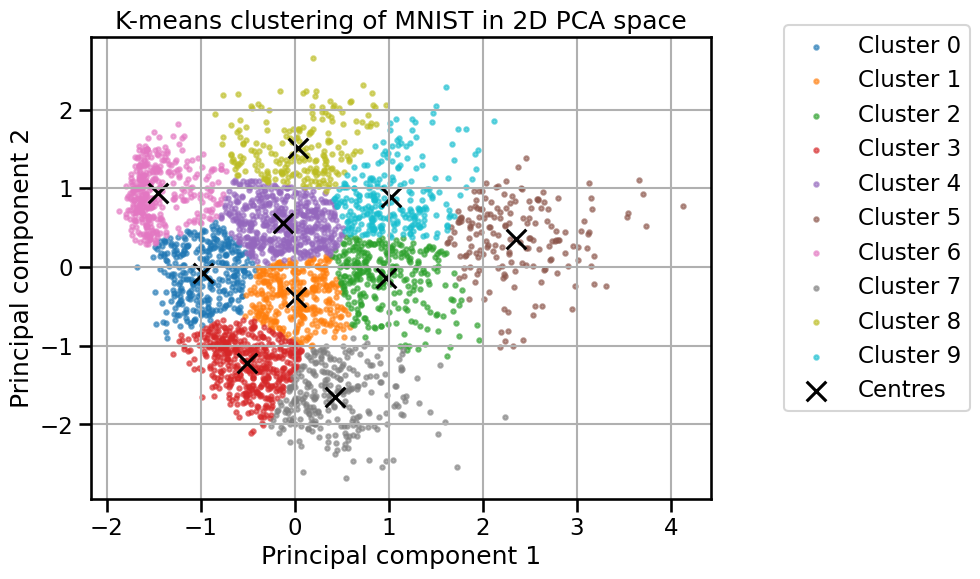

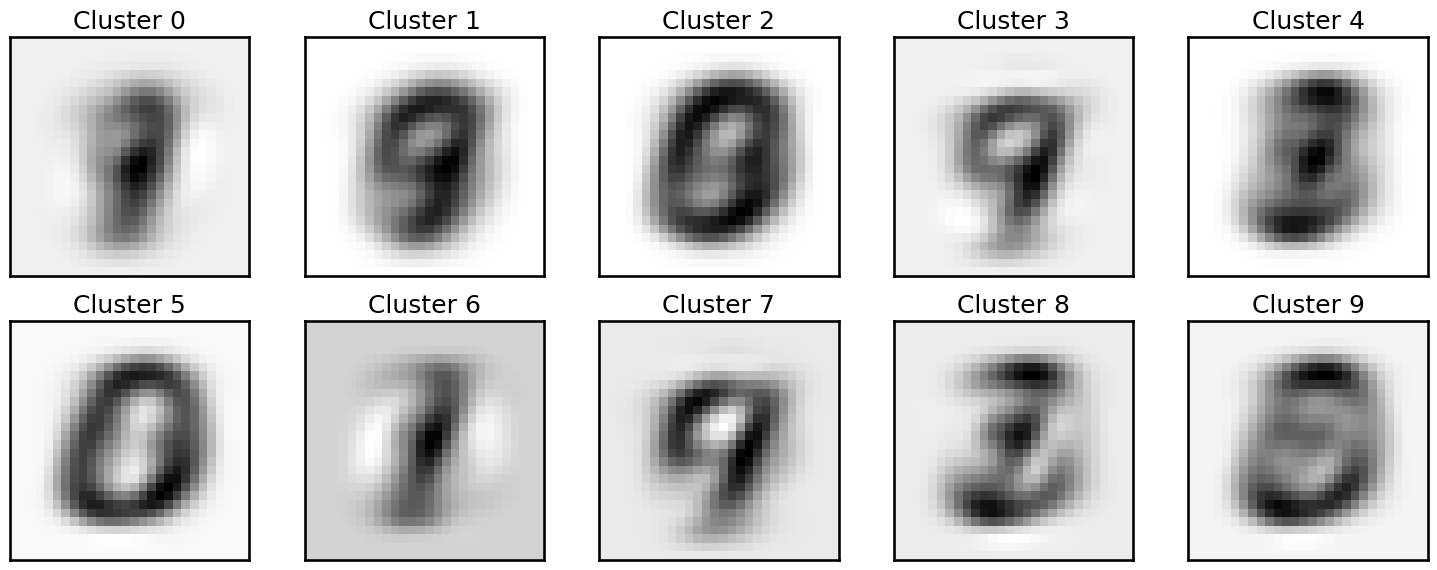

In [13]:
M = 2        # number of principal components
K = 10       # number of clusters
kmeans = KMeans(n_clusters=K, random_state=0) # KMeans object (change this!)

kmeans.fit(Z)

plt.figure(figsize=(8, 6))

for i in range(K):
    cluster_points = Z[kmeans.labels_ == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], s=10, alpha=0.6, label=f"Cluster {i}")

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker='x',
    s=200,
    c='black',
    label="Centres"
)

plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.title("K-means clustering of MNIST in 2D PCA space")
plt.legend(bbox_to_anchor=(1.1, 1.05))
plt.grid(True)
plt.show()

cluster_centres_img = pca.inverse_transform(kmeans.cluster_centers_)

fig, axs = plt.subplots(2, 5, figsize=(15, 6))
axs = axs.ravel()

for i in range(K):
    show_digit_image(cluster_centres_img[i], label=f"Cluster {i}", ax=axs[i])

plt.tight_layout()
plt.show()

In [14]:
assert isinstance(kmeans, KMeans)
assert kmeans.n_clusters == 10
assert len(kmeans.labels_) == 3000

### Question 2.c

- With reference to your answer to Question 2.b, how many cluster centers are digits, and how many aren't?
- Why do some of the cluster centers look like a mix of different digits
- Are there any relevant limitations of $K$-means approach here?

<div align="right">[5 points]</div>

None of the centres cleanly correspond to a specific digit apart from clusters 3, 5 and 7 (where 3 and 7 look near identical). The K-means centroids are the averages of many images, and since clusters will have some overlap with digits, the centroid is a pixelwise average of these multiple digits, generating this blurry hybrid image in reconstruction. This could be a result of compressing the original 784-dimensional data down to 2 dimensions, or as a result of assuming clusters are spherical in Euclidean space. Images form non-linear manifolds (https://www.robots.ox.ac.uk/~az/lectures/ml/lle.pdf), meaning this assumption is not fully satisfied.

### Extension Questions for Part 2

- Repeat the above analysis using three principal components instead of two. (The 2D visualization of the principal components will not make much sense; you could try to come up with an alternative). Pay attention to the identified cluster centers as images. Are they better or worse than before?

- Repeat the analysis with five principal components.

- Repeat the analysis with 200 principal components.

<div align="right">[5 points code + 5 points discussion]</div>

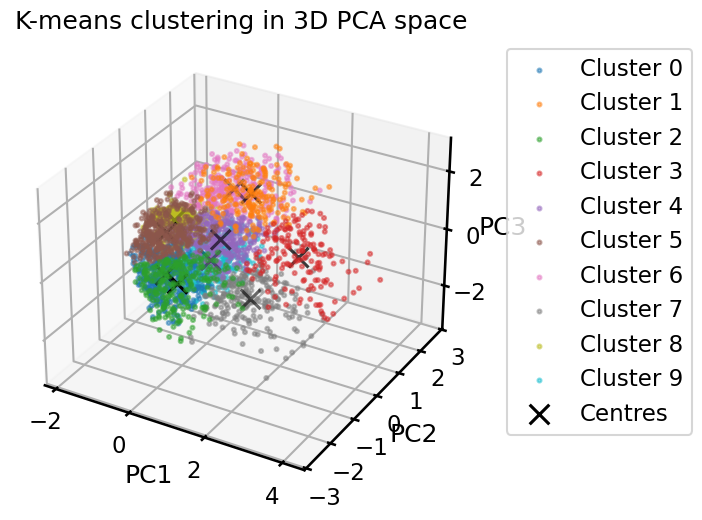

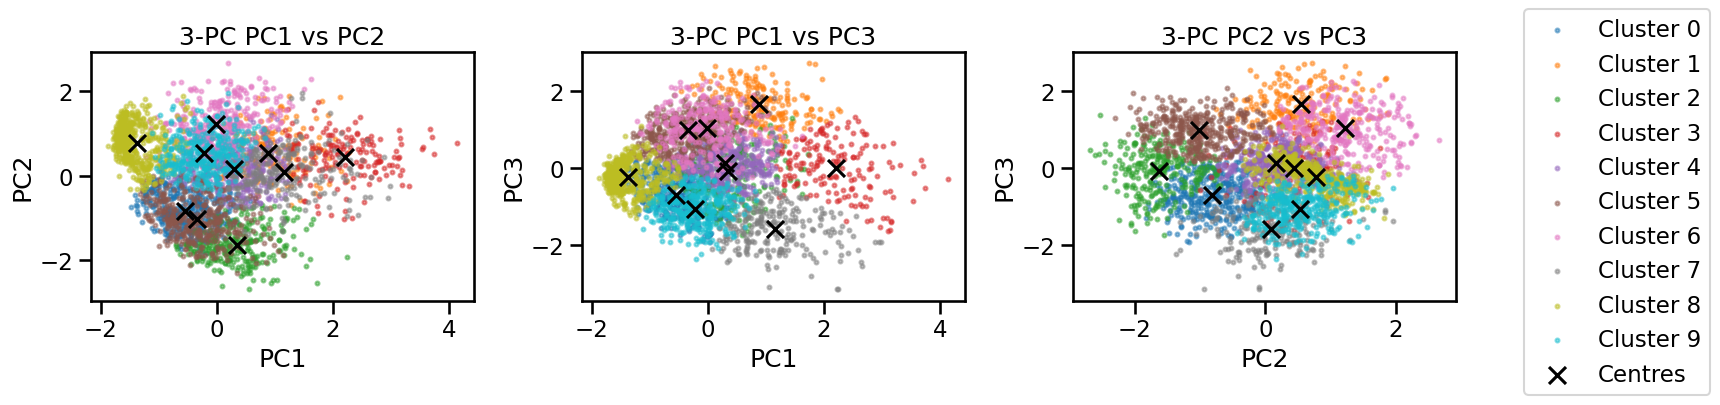

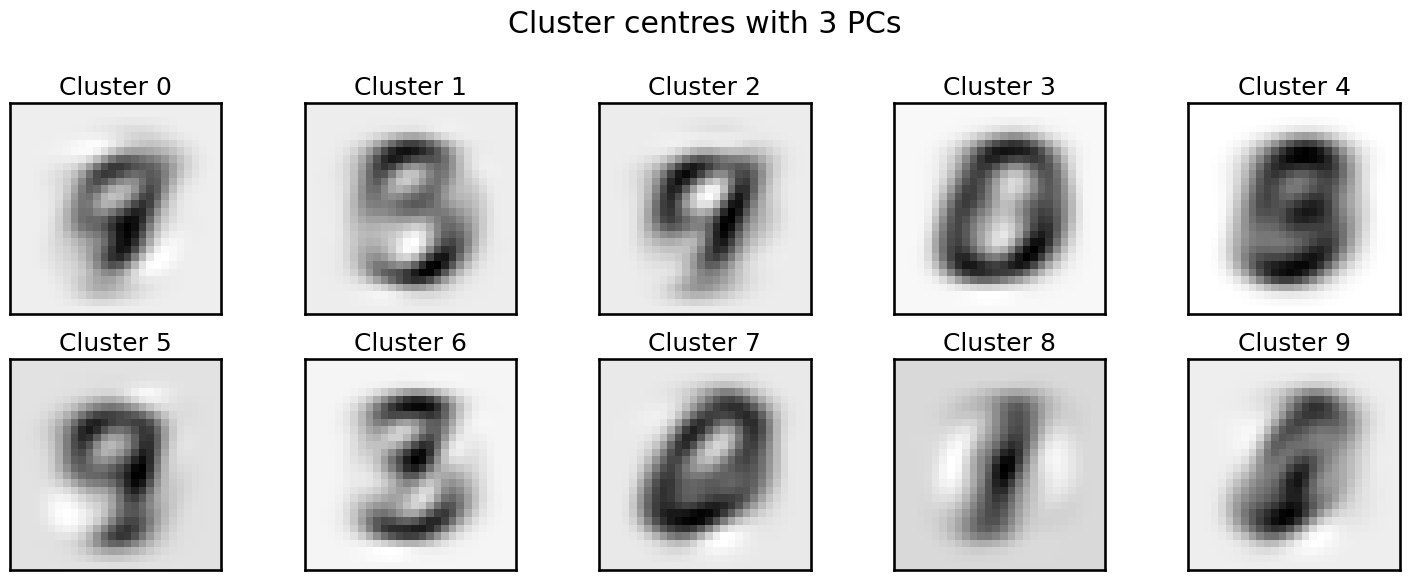

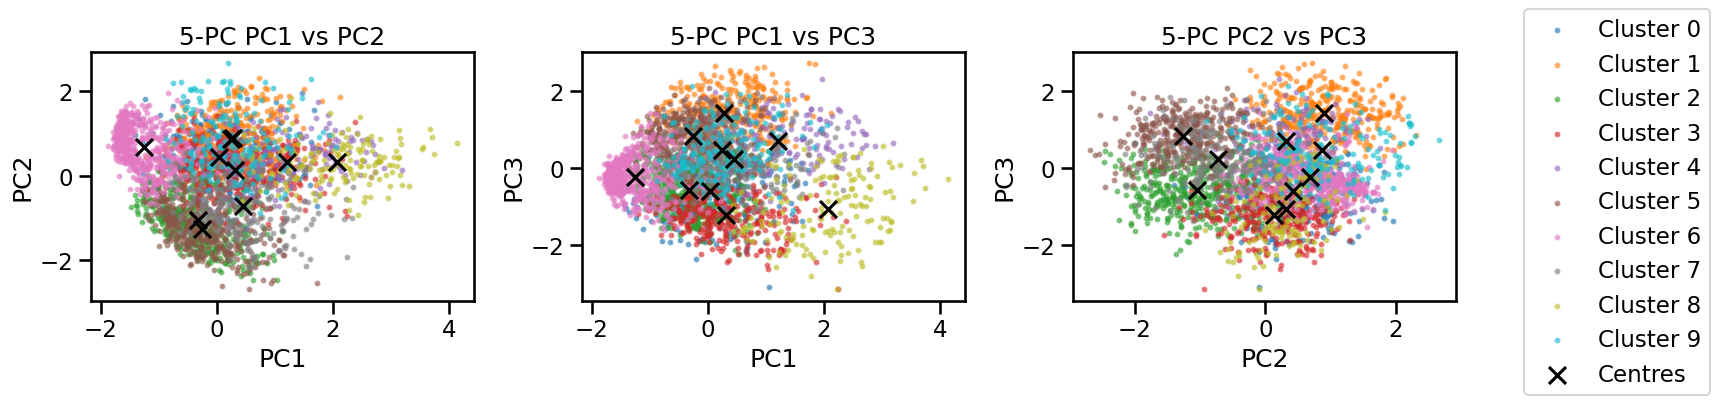

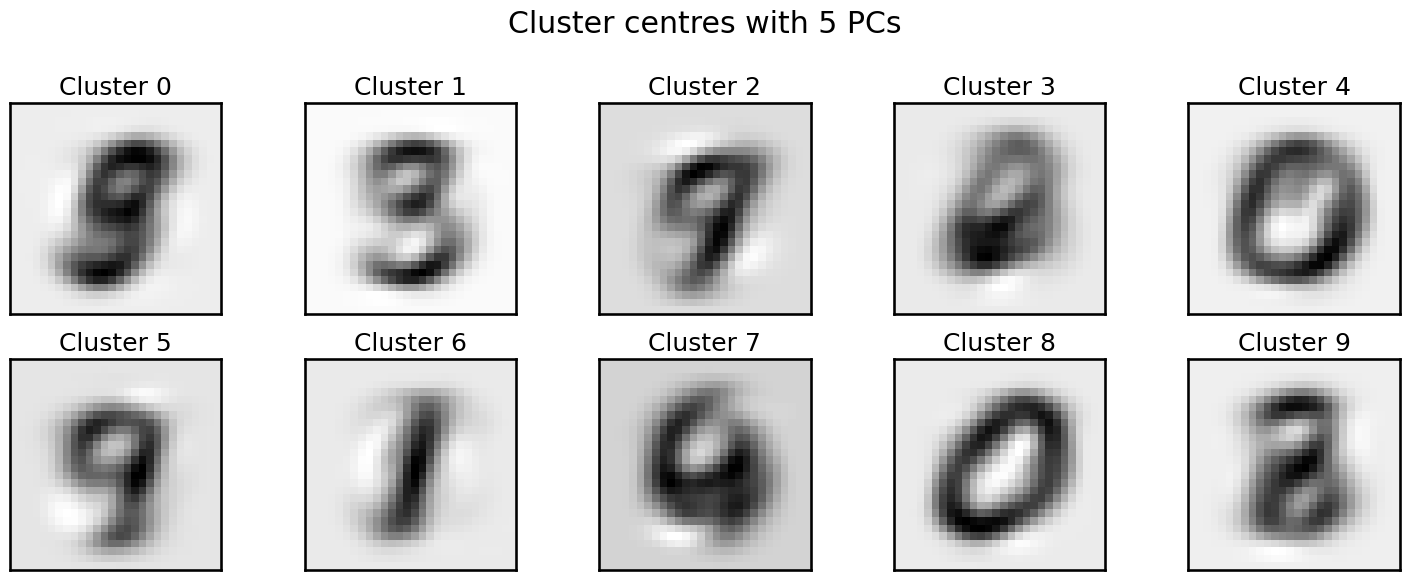

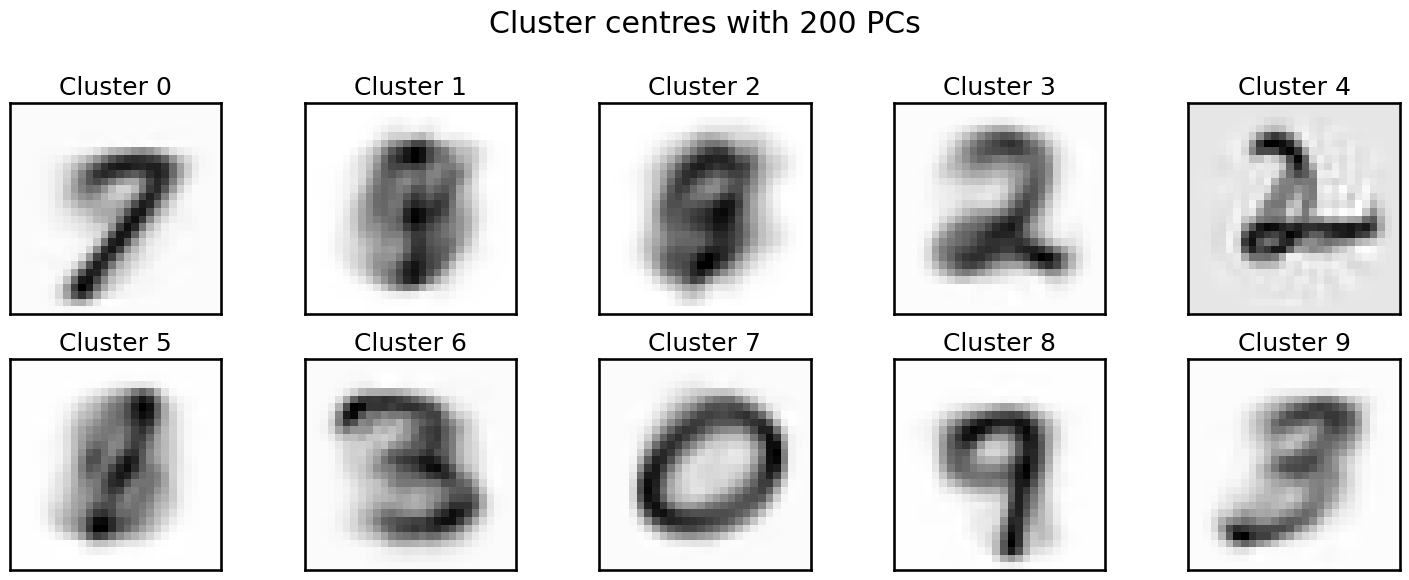

In [15]:
def run_pca_kmeans(X, n_components, n_clusters=10, n_samples=3000, random_state=0):
    pca = PCA(n_components=n_components, whiten=True)
    pca.fit(X)

    Z = pca.transform(X[:n_samples])

    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)
    kmeans.fit(Z)

    centres_img = pca.inverse_transform(kmeans.cluster_centers_)

    return pca, Z, kmeans, centres_img

def plot_3d_clusters(Z, kmeans, title="3D PCA + K-means"):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    for i in range(kmeans.n_clusters):
        pts = Z[kmeans.labels_ == i]
        ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=8, alpha=0.5, label=f"Cluster {i}")

    ax.scatter(
        kmeans.cluster_centers_[:, 0],
        kmeans.cluster_centers_[:, 1],
        kmeans.cluster_centers_[:, 2],
        c='black',
        marker='x',
        s=200,
        label='Centres'
    )

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

def plot_pairwise_components(Z, kmeans, dims=None, title_prefix=""):
    if dims is None:
        dims = list(range(Z.shape[1]))

    pairs = []
    for i in range(len(dims)):
        for j in range(i + 1, len(dims)):
            pairs.append((dims[i], dims[j]))

    fig, axs = plt.subplots(1, len(pairs), figsize=(5 * len(pairs), 4))
    if len(pairs) == 1:
        axs = [axs]

    for ax, (i, j) in zip(axs, pairs):
        for c in range(kmeans.n_clusters):
            pts = Z[kmeans.labels_ == c]
            ax.scatter(pts[:, i], pts[:, j], s=8, alpha=0.5, label=f"Cluster {c}")

        ax.scatter(
            kmeans.cluster_centers_[:, i],
            kmeans.cluster_centers_[:, j],
            c='black',
            marker='x',
            s=150,
            label='Centres'
        )

        ax.set_xlabel(f"PC{i+1}")
        ax.set_ylabel(f"PC{j+1}")
        ax.set_title(f"{title_prefix} PC{i+1} vs PC{j+1}")

    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

def plot_cluster_centres_as_images(centres_img, n_clusters=10, title_prefix=""):
    fig, axs = plt.subplots(2, 5, figsize=(15, 6))
    axs = axs.ravel()

    for i in range(n_clusters):
        show_digit_image(centres_img[i], label=f"Cluster {i}", ax=axs[i])

    plt.suptitle(title_prefix)
    plt.tight_layout()
    plt.show()

# apply the helper functions
pca3, Z3, kmeans3, centres3 = run_pca_kmeans(X_train, 3)
plot_3d_clusters(Z3, kmeans3, title="K-means clustering in 3D PCA space")
plot_pairwise_components(Z3, kmeans3, title_prefix="3-PC")
plot_cluster_centres_as_images(centres3, title_prefix="Cluster centres with 3 PCs")

pca5, Z5, kmeans5, centres5 = run_pca_kmeans(X_train, 5)
plot_pairwise_components(Z5[:, :3], kmeans5, dims=[0, 1, 2], title_prefix="5-PC")
plot_cluster_centres_as_images(centres5, title_prefix="Cluster centres with 5 PCs")

pca200, Z200, kmeans200, centres200 = run_pca_kmeans(X_train, 200)
plot_cluster_centres_as_images(centres200, title_prefix="Cluster centres with 200 PCs")

The cluster centres have a considerable improvement as the number of PCs increases. For the cluster centrs with 3 PCs, they are less blurred than in the 2-dimensional case however they are still ambiguous. For the 5 PC case, the cluster centres are more distinguishable where several centres correspond directly to different digits. However, there is still ambiguity for which numbers they represent. In the 200 PC case, numbers are far more recognisable, preserving more information from the compression than in the earlier cases. This matches the expected behaviour: higher dimensional PCA preserves more variance and structural information.

## Part 3. A Generative Gaussian Mixture Model

In this part of the workshop we will train a Gaussian mixture model (GMM) on a subset of the MNIST dataset as a simple example of a generative model. This is a slightly different application of GMMs that that demonstrated in the lecture, where we used GMMs as a 'fuzzy' $K$-means for clustering. Here, we are instead trying to find a representation of the probabilty density for MNIST images given a series of observations, so that we can generated new samples.

We seek to learn the parameters $\boldsymbol\phi$ of a probabilistic generative model $\mathbf{P}(\mathbf{x},\boldsymbol\phi)$ given a set of observations $X=(\mathbf{x}_1, \ldots, \mathbf{x}_N)$. The model form is 
$$
\mathbb{P}(\mathbf{x}) = \sum_{i=1}^K \lambda_k \mathcal{N}(\mathbf{x}|\boldsymbol\mu_k, \Sigma_k)
$$
where $\lambda_k$, $\boldsymbol\mu_k$ and $\Sigma_k$ are parameters we need to estimate from the data and $K$ is the number of mixture components.

We'll use scikit-learn's [GaussianMixture](https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html#sklearn.mixture.GaussianMixture) implementation, which maximises the log likelihood of the data $X$, given by

$$
\log \mathbb{P}(X|\boldsymbol{\lambda},\boldsymbol{\mu},\boldsymbol{\Sigma}) = \sum_{i=1}^n\log\left[\sum_{k=1}^K\lambda_k\mathcal{N}(\mathbf{x}_i|\boldsymbol{\mu}_k,\boldsymbol{\Sigma}_k)\right]
$$

where $\boldsymbol{\lambda} = (\lambda_1,\ldots,\lambda_K)$, $\boldsymbol{\mu} = (\boldsymbol{\mu}_1,\ldots,\boldsymbol{\mu}_K)$, and $\boldsymbol{\Sigma} = (\boldsymbol{\Sigma}_1,\ldots,\boldsymbol{\Sigma}_K)$. This is done using an Expectation-Maximisation (EM) algorithm by alternately computing the expected values of the conditional distribution of the latent variables given the observed data (E-step) and maximises the expected values of the log-likelihood with respect to the parameters (M-step).

In lectures we briefly discussed the challenge of choosing the number of mixture components $K$ to balance model complexity with accuracy without overfitting. The ideal way to do this would be a fully Bayesian approach of putting a prior on $K$, then estimate the posterior over the parameters by combining this prior with a likelihood coming from the observations.

Here, we introduce a simpler approach to avoid overfitting using the [Bayesian Information Criterion](https://en.wikipedia.org/wiki/Bayesian_information_criterion) (BIC). This is given by

$$
\text{BIC} = -2\log L + p \log N
$$

where $L = \mathbb{P}(X|\boldsymbol\phi) $ is the likelihood of the data with the optimised parameters $\boldsymbol\phi \in \mathbb{R}^p$, $p$ is the number of parameters and $N$ is the number of observations. The idea is trade off model fit (via the likelihood in the first term) with model complexity (via the second term). The smaller the BIC, the better the model.

To make the process manageable, we will first use PCA to project to a low-dimensional space and carry out the Gaussian mixture model fitting and sampling there before transforming back to the data space to visualise the results.

### Question 3.a

**Train a PCA model on all the 3s in the training set and use this to fit a GaussianMixture model**

- Use two components in the PCA model on all the 3s in `X_train`. As before use `whiten=True`. Name your PCA object `pca` as in the template code.
- Use the PCA model to reduce the dimensionality of all the 3s data
- Fit a scikit-learn [GaussianMixture](https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html#sklearn.mixture.GaussianMixture) model to the low dimensional representation of the 3s. Name it `model`.
- You will need to choose a number of components for your mixture model. Use the BIC available from the [GaussianMixture.bic()](https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html#sklearn.mixture.GaussianMixture.bic) method after fitting to help with model selection; choose the model with minimum BIC. 
- Plot a graph showing the contributions to the BIC (negative likelihood $-2\log L$ and complexity penalty $p \log N$) to support your choice

<div align="right">[5 points code + 5 points plot]</div>

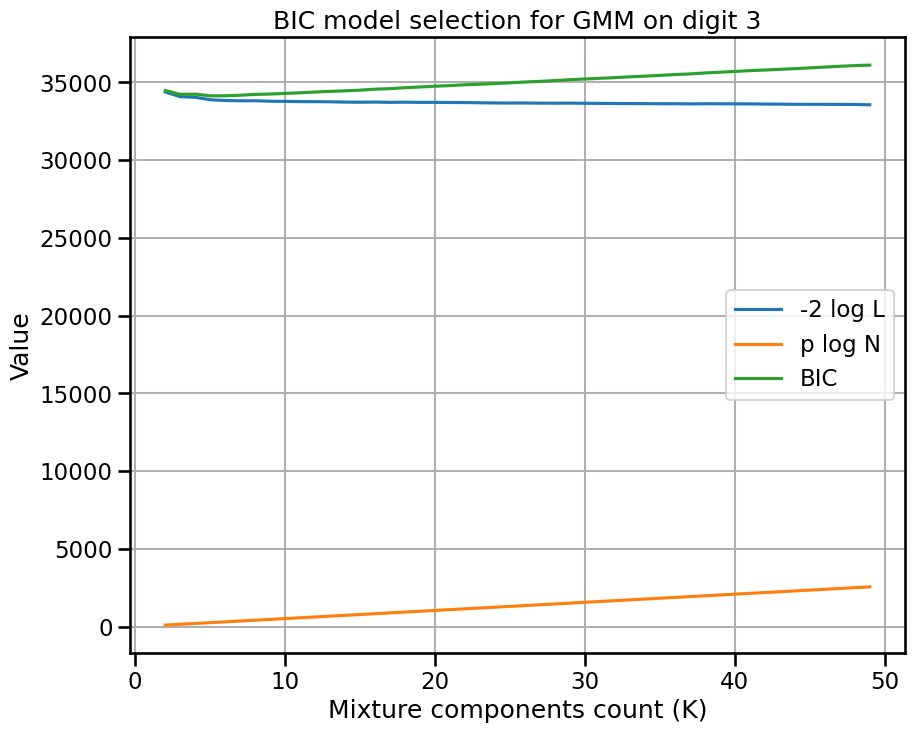

In [17]:
X_train_3 = X_train[y_train == '3']
pca = PCA(n_components=2, whiten=True)
Z = pca.fit_transform(X_train_3)
diff_ks = range(2, 50)

complexity = []
nll = []
bics = []

for k in diff_ks:
    GMM = GaussianMixture(n_components=k, random_state=0)
    GMM.fit(Z)

    bic = GMM.bic(Z)
    bics.append(bic)

    ll = GMM.score(Z) * Z.shape[0]
    nll.append(-2 * ll)

    p = GMM._n_parameters()
    complexity.append(p * np.log(Z.shape[0]))

k_best = diff_ks[np.argmin(bics)]
model = GaussianMixture(n_components=k_best, random_state=0)
model.fit(Z)

plt.figure()

plt.plot(diff_ks, nll, label='-2 log L')
plt.plot(diff_ks, complexity, label='p log N')
plt.plot(diff_ks, bics, label='BIC')

plt.xlabel("Mixture components count (K)")
plt.ylabel("Value")
plt.title("BIC model selection for GMM on digit 3")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
assert isinstance(pca, PCA)
assert pca.whiten
assert pca.n_components == 2

assert isinstance(model, GaussianMixture)
assert model.n_components > 1 and model.n_components < 100


### Question 3.b

**Produce 25 samples from your model and visualise them in the original image data space**

*Hints*:
- You can use the [GaussianMixture.sample()](https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html#sklearn.mixture.GaussianMixture.sample) method to generate samples
- You will need to invert the PCA transformation after sampling

<div align="right">[5 points]</div>

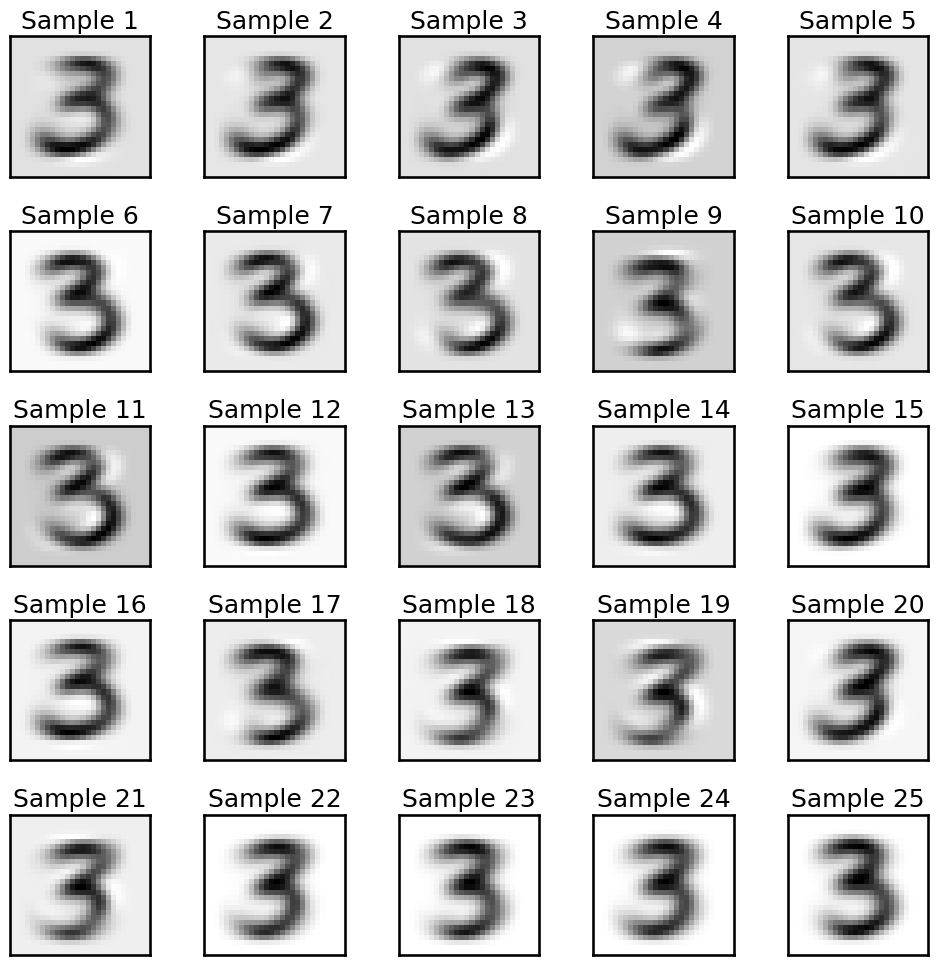

In [20]:
Zs, labels = model.sample(25)
Xs = pca.inverse_transform(Zs)

fig, axs = plt.subplots(5, 5, figsize=(10, 10))
axs = axs.ravel()

for i in range(25):
    show_digit_image(Xs[i], ax=axs[i], label=f"Sample {i+1}")

plt.tight_layout()
plt.show()

### Extension Questions for Part 3 (Not for Credit)

- Try making a generative model for other digits instead of threes. Does it work better or worse? Why might this be?
- Try increasing the number of PCA components (e.g. to 3, 5 or 10). Do the results improve or become worse? Why might this be?

In [ ]:
##

## Part 4. Molecular Conformations Analysis

In this final part, we apply unsupervised learning to a Scientific Machine Learning problem: analysing molecular conformations from a molecular dynamics simulation. This is a common task in computational chemistry and materials science, where we want to understand the different structural states a molecule can adopt.

We will work with a synthetic dataset representing a triatomic molecule that can exist in two conformations: a "bent" state and a "linear" state. Each configuration is described by the $(x, y)$ coordinates of 3 atoms, giving us 6 features per sample. Our goals are to:

1. Use PCA to reduce dimensionality and visualise the conformational landscape
2. Use $K$-means clustering to identify distinct conformational states
3. Interpret the results in terms of molecular structure

Trajectory shape: (1000, 6)
Features: [x1, y1, x2, y2, x3, y3] for each configuration


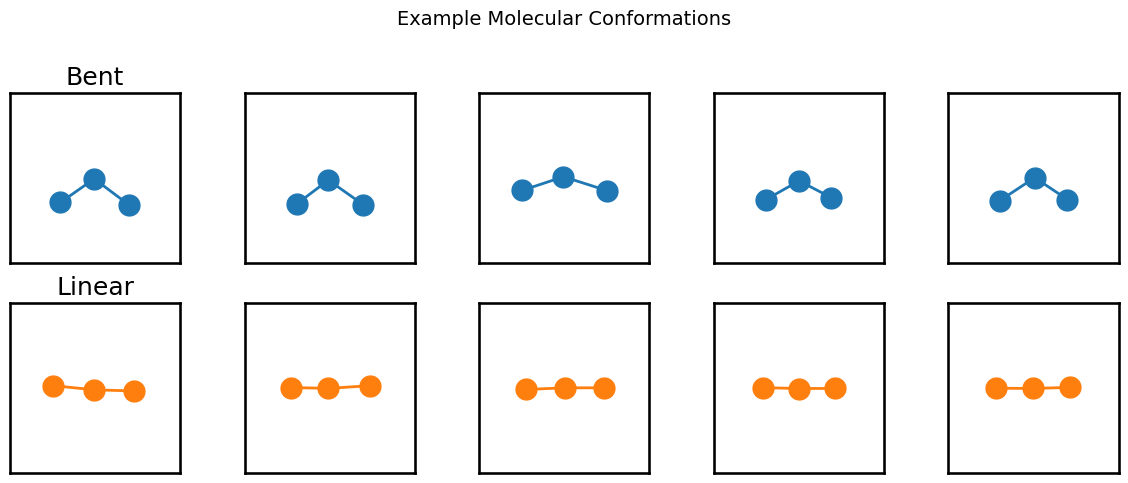

In [21]:
# Generate synthetic molecular trajectory data
np.random.seed(42)

def generate_molecular_trajectory(n_samples=1000):
    """
    Generate synthetic molecular dynamics trajectory for a triatomic molecule.

    The molecule can exist in two conformations:
    - Bent: atoms at roughly 120 degree angle
    - Linear: atoms in a straight line

    Returns positions as (n_samples, 6) array: [x1, y1, x2, y2, x3, y3]
    """
    trajectory = []
    labels = []

    for i in range(n_samples):
        # Randomly choose conformation (60% bent, 40% linear)
        if np.random.random() < 0.6:
            # Bent conformation: middle atom at origin, others at ~120 degrees
            angle = np.pi * 2/3 + np.random.normal(0, 0.2)  # ~120 degrees with noise
            bond_length = 1.5 + np.random.normal(0, 0.1)

            # Atom positions
            x1, y1 = -bond_length * np.sin(angle/2), -bond_length * np.cos(angle/2)
            x2, y2 = 0.0, 0.0  # Central atom at origin
            x3, y3 = bond_length * np.sin(angle/2), -bond_length * np.cos(angle/2)
            labels.append(0)  # Bent
        else:
            # Linear conformation: atoms in a line
            bond_length = 1.4 + np.random.normal(0, 0.08)

            x1, y1 = -bond_length, np.random.normal(0, 0.05)
            x2, y2 = 0.0, 0.0
            x3, y3 = bond_length, np.random.normal(0, 0.05)
            labels.append(1)  # Linear

        # Add thermal noise to all positions
        noise = np.random.normal(0, 0.05, 6)
        positions = np.array([x1, y1, x2, y2, x3, y3]) + noise

        trajectory.append(positions)

    return np.array(trajectory), np.array(labels)

# Generate trajectory
X_mol, y_mol_true = generate_molecular_trajectory(n_samples=1000)
print(f"Trajectory shape: {X_mol.shape}")
print(f"Features: [x1, y1, x2, y2, x3, y3] for each configuration")

# Visualise a few example configurations
def plot_molecule(positions, ax, title=None, color='C0'):
    """Plot a single molecular configuration."""
    x = positions[::2]  # x1, x2, x3
    y = positions[1::2]  # y1, y2, y3
    ax.plot(x, y, 'o-', markersize=15, linewidth=2, color=color)
    ax.set_aspect('equal')
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    if title:
        ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

fig, axs = plt.subplots(2, 5, figsize=(12, 5))
# Show 5 bent and 5 linear examples
bent_idx = np.where(y_mol_true == 0)[0][:5]
linear_idx = np.where(y_mol_true == 1)[0][:5]

for i, idx in enumerate(bent_idx):
    plot_molecule(X_mol[idx], axs[0, i], 'Bent' if i == 0 else None, 'C0')
for i, idx in enumerate(linear_idx):
    plot_molecule(X_mol[idx], axs[1, i], 'Linear' if i == 0 else None, 'C1')

fig.suptitle('Example Molecular Conformations', fontsize=14)
plt.tight_layout()

### Question 4.a

**Apply PCA to the molecular trajectory and visualise the conformational landscape**

- Fit a PCA model with 2 components to `X_mol` (no whitening needed here)
- Transform the data and create a scatter plot of the first two principal components
- Colour the points by the true labels (`y_mol_true`) to see if PCA separates the conformations
- Report the fraction of variance explained by the first two components

<div align="right">[10 points]</div>

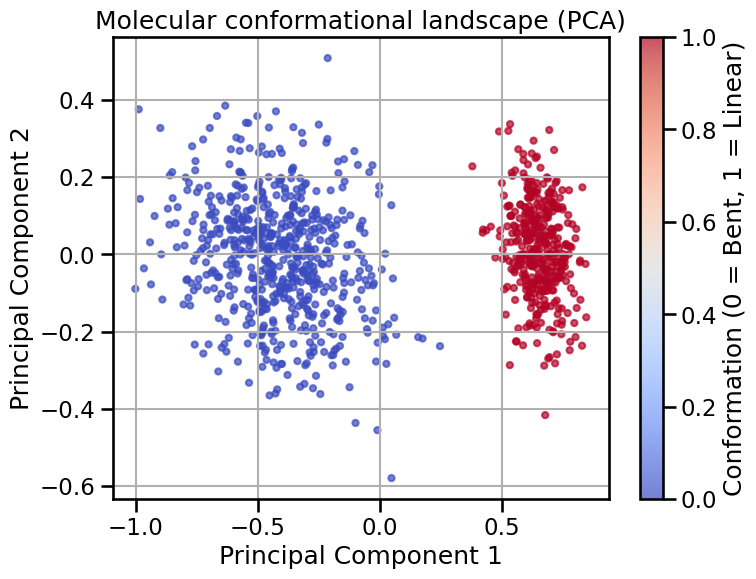

Variance explained by PC1: 0.9054349598312011
Variance explained by PC2: 0.06161447319628995
Total variance explained: 0.9670494330274911


In [22]:
pca_mol = PCA(n_components=2)
Z_mol = pca_mol.fit_transform(X_mol)

plt.figure(figsize=(8,6))

plt.scatter(
    Z_mol[:,0],
    Z_mol[:,1],
    c=y_mol_true,
    cmap='coolwarm',
    s=20,
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Molecular conformational landscape (PCA)")
plt.colorbar(label="Conformation (0 = Bent, 1 = Linear)")
plt.grid(True)
plt.show()

explained_variance = pca_mol.explained_variance_ratio_
print("Variance explained by PC1:", explained_variance[0])
print("Variance explained by PC2:", explained_variance[1])
print("Total variance explained:", explained_variance.sum())

In [23]:
assert isinstance(pca_mol, PCA)
assert pca_mol.n_components == 2
assert Z_mol.shape == (1000, 2)
assert pca_mol.explained_variance_ratio_.sum() > 0.5  # Should explain significant variance

### Question 4.b

**Use $K$-means clustering to identify conformational states**

- Apply $K$-means clustering with $K=2$ clusters to the PCA-reduced molecular data `Z_mol`
- Create a scatter plot showing the clustering results, with cluster centres marked
- Calculate and print the clustering accuracy by comparing to the true labels

*Hint:* Since cluster labels are arbitrary, you may need to swap them to match the true labels when computing accuracy.

<div align="right">[10 points]</div>

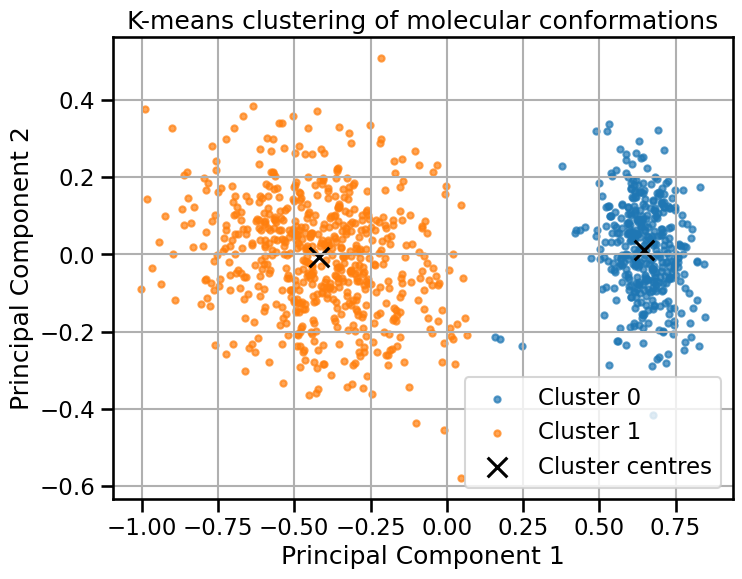

Clustering accuracy: 0.997


In [25]:
kmeans_mol = KMeans(n_clusters=2, random_state=0)
mol_prediction = kmeans_mol.fit_predict(Z_mol)

plt.figure(figsize=(8, 6))

for k in range(2):
    pts = Z_mol[mol_prediction == k]
    plt.scatter(pts[:, 0], pts[:, 1], s=20, alpha=0.7, label=f"Cluster {k}")

plt.scatter(
    kmeans_mol.cluster_centers_[:, 0],
    kmeans_mol.cluster_centers_[:, 1],
    marker='x',
    s=200,
    c='black',
    label='Cluster centres'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-means clustering of molecular conformations")
plt.legend()
plt.grid(True)
plt.show()

acc1 = np.mean(mol_prediction == y_mol_true)
acc2 = np.mean((1 - mol_prediction) == y_mol_true)
accuracy = max(acc1, acc2)

print("Clustering accuracy:", accuracy)

In [26]:
assert isinstance(kmeans_mol, KMeans)
assert kmeans_mol.n_clusters == 2
assert len(kmeans_mol.labels_) == 1000

# Check that clustering achieves reasonable accuracy (>80%)
accuracy1 = np.mean(kmeans_mol.labels_ == y_mol_true)
accuracy2 = np.mean(kmeans_mol.labels_ == (1 - y_mol_true))
accuracy = max(accuracy1, accuracy2)
assert accuracy > 0.8, f"Clustering accuracy {accuracy:.1%} is too low"

### Question 4.c

**Interpret your results**

Based on your analysis, answer the following questions:

1. What physical meaning might the first principal component have in terms of molecular structure?
2. Why might this approach work less well if the molecules were also randomly rotated in the training data?
3. In what ways might this analysis approach be useful for analysing real molecular dynamics trajectories?

<div align="right">[5 points]</div>

The first principal component corresponds to the bond angle bertween the three atoms. Going along PC1 corresponds to a transition from bent to linear geometric configuration for the molecule.

If molecules were randomly rotated, the Cartesian representation of the molecule would change despite the molecular geometry being identical. In turn, PCA would find variance in rotational variation rather than the difference in molecular structure, reducing the algorithm's ability to separate the two classes, highlighting the importance for rotation-invariant representation.

For high-dimensional molecular dynamics simulation, PCA offers a method to reduce the dimensions to retrieve the primary underlying motion mechanics of a molecule in a lower-dimensional setting. Clustering methods can be used to group molecules by geometric representation (i.e. folded/unfolded proteins, ligand binding poses), giving a simple yet powerful method to characterise state transitions!